# Aplicando modelos, escolhendo um e treinando a base

In [1]:
#Importações
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import (MinMaxScaler, PowerTransformer, StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder)

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from joblib import dump

from Apoio.auxiliares import dataframe_coeficientes
from Apoio.config import DADOS_TRATADOS, MODELO_FINAL
from Apoio.graficos import plot_comparar_metricas_modelos, plot_coeficientes
from Apoio.models_rus import RANDOM_STATE
from Apoio.models_rus import (grid_search_cv_classificador, treinar_e_validar_modelo_classificacao, organiza_resultados)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [3]:
categoricas_nao_ordenadas = ["BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]

categoricas_ordenadas = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel", "JobSatisfaction", "PerformanceRating",
                        "RelationshipSatisfaction", "StockOptionLevel", "WorkLifeBalance"]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns 
    if coluna not in (categoricas_nao_ordenadas+categoricas_ordenadas+coluna_alvo)
]

In [4]:
with pd.option_context("display.max_columns", 31):
    display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


### Transformações das colunas numéricas:

In [6]:
colunas_numericas_minMax = ["DailyRate", "HourlyRate", "MonthlyRate"]

colunas_numericas_Std = ["Age"]

colunas_numericas_PowerTransformer = [
    coluna for coluna in colunas_numericas 
    if coluna not in (colunas_numericas_minMax+colunas_numericas_Std)
]

Como escolher a transformação?

- Distribuição aproximadamente normal → StandardScaler.
- Distribuição muito assimétrica → PowerTransformer.
- Necessidade de limitar os valores entre 0 e 1 → MinMaxScaler.

In [7]:
X = df.drop(columns=coluna_alvo)
y = df[coluna_alvo]

### Aplicando um pré-processamento na coluna alvo (attrition)

In [9]:
le = LabelEncoder()
y = le.fit_transform(y.values.ravel())

In [11]:
y[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### Fazendo a separação dos dados em 5 partes

In [12]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Criando os pré-processamentos

In [16]:
preprocessamento_arvore = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), categoricas_nao_ordenadas),
        ("ordinal", OrdinalEncoder(categories="auto"), categoricas_ordenadas),
    ]
)

preprocessamento = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first"), categoricas_nao_ordenadas),
        ("ordinal", OrdinalEncoder(categories="auto"), categoricas_ordenadas),
        ("min_max", MinMaxScaler(), colunas_numericas_minMax),
        ("stdscaler", StandardScaler(), colunas_numericas_Std),
        ("power_transform", PowerTransformer(), colunas_numericas_PowerTransformer)
    ]
)

### Criando os classificadores

In [18]:
classificadores = {
    "DummyClassifier": {"preprocessor": None, "classificador": DummyClassifier(strategy="stratified")},
    
    "LogisticRegression": {"preprocessor": preprocessamento, "classificador": LogisticRegression()},
    
    "DecisionTreeClassifier": {"preprocessor": preprocessamento_arvore, "classificador": DecisionTreeClassifier()},
    
    "LGBMClassifier": {"preprocessor": preprocessamento_arvore, "classificador": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)},
    
    "XGBClassifier": {"preprocessor": preprocessamento_arvore, "classificador": XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1)},
    
    "SVC": {"preprocessor": preprocessamento, "classificador": SVC()},
    
    "KNeighborsClassifier": {"preprocessor": preprocessamento, "classificador": KNeighborsClassifier()}
}

### Comparação dos classificadores

In [22]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.216524,0.143763,0.47619,0.494157,0.245098,0.160256,0.520833,0.493648,0.161568,0.360287
1,DummyClassifier,0.015951,0.038365,0.445578,0.425559,0.189055,0.124183,0.395833,0.551575,0.179911,0.054317
2,DummyClassifier,0.020476,0.016929,0.517007,0.523042,0.260417,0.172414,0.531915,0.45973,0.150531,0.037405
3,DummyClassifier,0.0,0.012767,0.547619,0.567103,0.296296,0.197183,0.595745,0.506331,0.161601,0.012767
4,DummyClassifier,0.015731,0.015704,0.537415,0.569644,0.298969,0.197279,0.617021,0.472392,0.153146,0.031435
5,LogisticRegression,0.737388,0.074375,0.707483,0.724593,0.455696,0.327273,0.75,0.798103,0.548634,0.811763
6,LogisticRegression,0.123763,0.063339,0.768707,0.744411,0.5,0.386364,0.708333,0.825373,0.565305,0.187102
7,LogisticRegression,0.131851,0.055587,0.72449,0.749892,0.477419,0.342593,0.787234,0.846326,0.65278,0.187438
8,LogisticRegression,0.128039,0.04268,0.751701,0.748859,0.48951,0.364583,0.744681,0.834783,0.608646,0.170719
9,LogisticRegression,0.107024,0.034521,0.758503,0.735679,0.481752,0.366667,0.702128,0.776036,0.572919,0.141545


In [24]:
df_resultados.groupby("model").mean().sort_values("test_average_precision")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.053736,0.045506,0.504762,0.515901,0.257967,0.170263,0.53227,0.496735,0.161351,0.099242
DecisionTreeClassifier,0.022003,0.030723,0.670068,0.649972,0.376793,0.271075,0.620301,0.649972,0.231409,0.052725
KNeighborsClassifier,0.067277,0.157108,0.730612,0.665559,0.405845,0.31686,0.569592,0.728196,0.355607,0.224385
XGBClassifier,0.079856,0.036835,0.713605,0.69978,0.433511,0.318705,0.679344,0.772425,0.444113,0.116691
LGBMClassifier,0.073626,0.039373,0.72381,0.715876,0.451201,0.33224,0.704255,0.79084,0.482381,0.112999
LogisticRegression,0.245613,0.0541,0.742177,0.740687,0.480876,0.357496,0.738475,0.816124,0.589657,0.299713
SVC,0.078129,0.062893,0.765306,0.747714,0.500218,0.383697,0.72172,0.826207,0.61304,0.141022


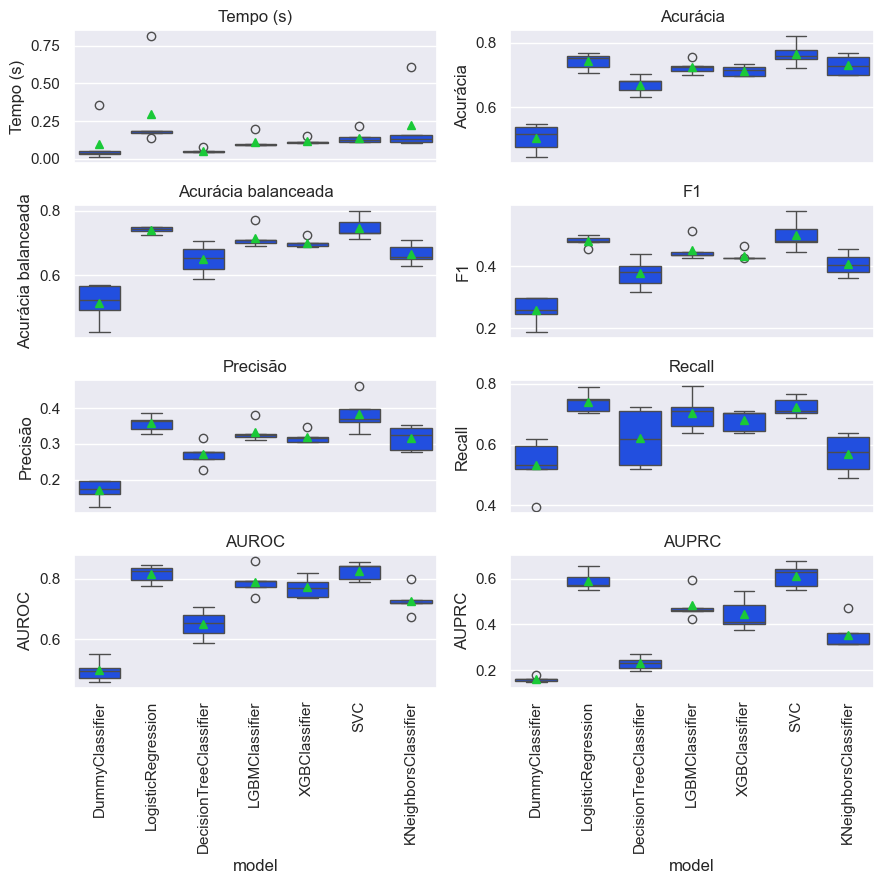

In [25]:
plot_comparar_metricas_modelos(df_resultados)